# GSE235663 初步分析
结肠组织 T细胞 样本，4个样本，1个来自HC，3个来自UC（排除两个不清楚类别的样本）   
3UC 1HC
- UC75-UC77
- HC95

# 文件说明
- **文件名**: 11_GSE235663.h5ad  
- **存放位置**: 坚果云  `UC/scRNA-seq_data/data_qc/`  
- **生成日期**: 2025-11-1
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/11_GSE235663_preprocessing.ipynb  
- **内容说明**: 包含质控和去除双细胞后的数据集数据，保存为h5ad文件，方便后续合并时读取  

In [1]:
import scanpy as sc
import omicverse as ov
ov.plot_set(dpi=50)
ov.settings.verbose = 1 
ov.settings.cpu_gpu_mixed_init()

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

CPU-GPU mixed mode activated


## 读取表达矩阵类型数据

In [2]:
import pandas as pd
import os

data_dir = "/mnt/e/UC/scRNA-seq_RAW/11_GSE235663"
adatas = []

for file in sorted(os.listdir(data_dir)):
    if not file.endswith(".txt"):
        continue

    path = os.path.join(data_dir, file)
    sample = os.path.splitext(file)[0]

    df = pd.read_csv(path, sep="\t", index_col=0)
    ad = sc.AnnData(df.T)
    sc.pp.filter_cells(ad, min_genes=200)
    sc.pp.filter_genes(ad, min_cells=3)

    #ad.obs['GSM_id'] = sample
    #ad.obs_names = [f"{sample}_{x}" for x in ad.obs_names]

    adatas.append(ad)

adata = sc.concat(adatas, merge='same')

In [3]:
adata

AnnData object with n_obs × n_vars = 15411 × 14203
    obs: 'n_genes'
    var: 'n_cells'

In [4]:
adata.obs.head()

,n_genes
AAAGATGAGGATGGTC.1,1363
AAAGATGAGGCCCGTT.1,2102
AAAGATGTCAAACCAC.1,2120
AAAGCAATCATATCGG.1,1282
AAAGTAGAGGAGTAGA.1,1549


In [5]:
import pandas as pd
import numpy as np

# 从obs_names里提取末尾的数字，放进一列，比如叫 "batch_code"
# 假设名字都是 like "XXXXX.1"
adata.obs['batch_code'] = adata.obs_names.str.split('.').str[-1]
adata.obs['batch_code'] = adata.obs['batch_code'].astype(int)
print("unique batch_code:", adata.obs['batch_code'].unique())

unique batch_code: [1 2 3 4 5 6]


In [6]:
# 根据 batch_code 删除掉 1 和 4 对应的所有细胞
cells_to_keep = ~adata.obs['batch_code'].isin([1, 4])
adata = adata[cells_to_keep].copy()

In [7]:
adata.obs['batch_code'].value_counts()

batch_code
6    4942
3    3466
2    1936
5     700
Name: count, dtype: int64

In [8]:
id_map = {
    2: 'UC75',
    3: 'HC95',
    5: 'UC76',
    6: 'UC77'
}

adata.obs['id'] = adata.obs['batch_code'].map(id_map)

gsm_map = {
    2: 'GSM7507205',
    3: 'GSM7507206',
    5: 'GSM7507217',
    6: 'GSM7507220'
}

adata.obs['GSM'] = adata.obs['batch_code'].map(gsm_map)

print(adata.obs[['batch_code','id','GSM']].head())

                    batch_code    id         GSM
AAACCTGAGCTACCGC.2           2  UC75  GSM7507205
AAACCTGAGTGCGATG.2           2  UC75  GSM7507205
AAACCTGCAGGATCGA.2           2  UC75  GSM7507205
AAACCTGGTTTAGGAA.2           2  UC75  GSM7507205
AAACCTGTCCCTTGCA.2           2  UC75  GSM7507205


In [9]:
adata.obs = adata.obs.drop(columns=['batch_code'])

In [10]:
adata

AnnData object with n_obs × n_vars = 11044 × 14203
    obs: 'n_genes', 'id', 'GSM'
    var: 'n_cells'

In [11]:
adata.obs['id'].value_counts()

id
UC77    4942
HC95    3466
UC75    1936
UC76     700
Name: count, dtype: int64

## 预处理步骤
- QC: mito<0.2, UMI>500, genes>250, 去除双细胞
- HVG: Pearson方法，2000个
- PCA: 50个PCs
- neighbors: 最邻近数15，使用前50PCs
- leiden: resolution0.5

In [12]:
# QC
adata=ov.pp.qc(adata,
               tresh={'mito_perc': 0.2, 'nUMIs': 500, 'detected_genes': 250},
               doublets_method='scrublet',
               batch_key=None)
adata

⚙️ Using CPU/GPU mixed mode for QC...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    ||||-------------------------- 2616/16311 MiB (16.0%)

🔍 Quality Control Analysis (CPU-GPU Mixed):
   Dataset shape: 11,044 cells × 14,203 genes
   QC mode: seurat
   Doublet detection: scrublet
   Mitochondrial genes: MT-

📊 Step 1: Calculating QC Metrics
   Mitochondrial genes (prefix 'MT-'): 13 found
   ✓ QC metrics calculated:
     • Mean nUMIs: 3917 (range: 507-8995)
     • Mean genes: 1588 (range: 331-2995)
     • Mean mitochondrial %: 0.0% (max: 0.1%)

🔧 Step 2: Quality Filtering (SEURAT)
   Thresholds: mito≤0.2, nUMIs≥500, genes≥250
   📊 Seurat Filter Results:
     • nUMIs filter (≥500): 0 cells failed (0.0%)
     • Genes filter (≥250): 0 cells failed (0.0%)
     • Mitochondrial filter (≤0.2): 0 cells failed (0.0%)
   ✓ Combined QC filters: 0 cells removed (0.0%)

🎯 Step 3: Final Filtering
   Parameters: min_genes=200, min_cells=3
   Ratios: max_genes_ratio=1, max_cells_ra

AnnData object with n_obs × n_vars = 11042 × 14202
    obs: 'n_genes', 'id', 'GSM', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'n_cells', 'mt'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU'

## 保存质控后数据（去除双细胞）

In [13]:
output_dir = "/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/data_qc/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "11_GSE235663.h5ad"), compression='gzip')

In [13]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.7)

Begin robust gene identification
After filtration, 14202/14202 genes are kept.     Among 14202 genes, 14202 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell
The following highly-expressed genes are not considered during normalization factor computation:
['IGJ']
    finished (0:00:01)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 9.878605127334595 seconds.
End of size normalization: shiftlog and HVGs selection pearson
🚀 Using GPU to calculate PCA...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    ||||||

In [14]:
adata

AnnData object with n_obs × n_vars = 11042 × 2000
    obs: 'n_genes', 'id', 'GSM', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'n_cells', 'mt', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'scaled|original|X_pca', 'X_umap'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'
    obsp: 'distances', 'connectivities'

In [15]:
adata.obs['id'].value_counts()

id
UC77    4940
HC95    3466
UC75    1936
UC76     700
Name: count, dtype: int64

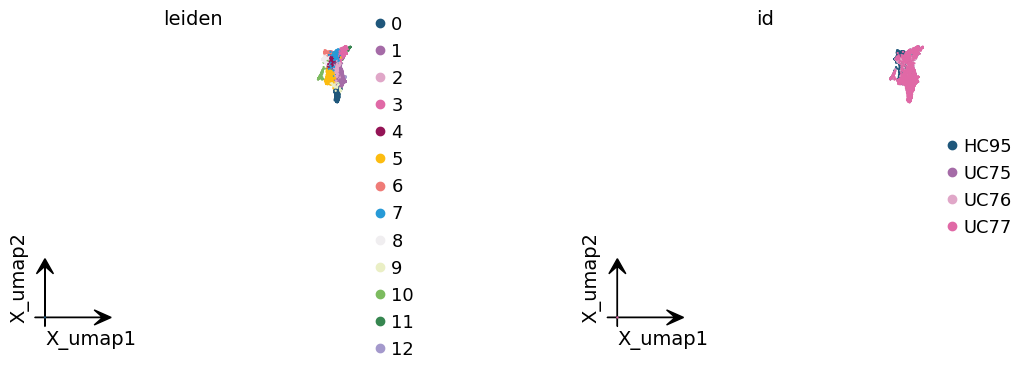

In [16]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'id'],
                frameon='small',
                wspace=0.5)

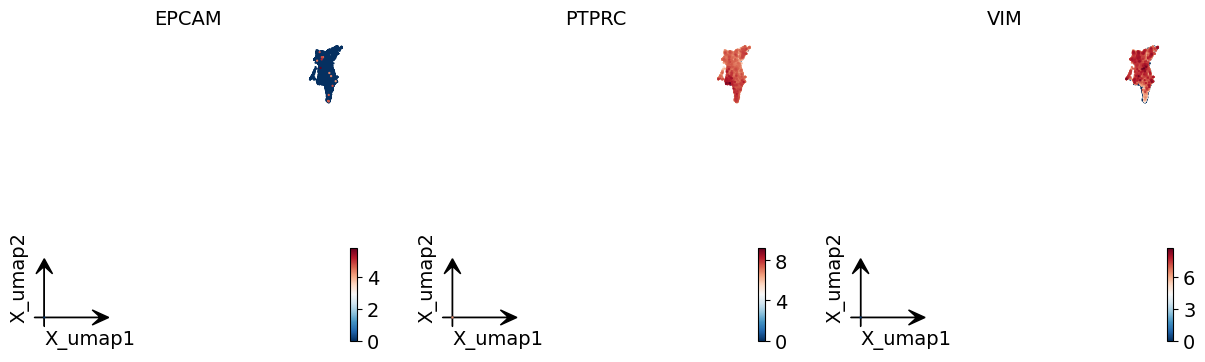

In [17]:
# 粗略查看上皮、免疫、基质细胞
ov.pl.embedding(adata,
                basis='X_umap',
                color=['EPCAM', 'PTPRC', 'VIM'],
                frameon='small')

In [18]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:06)


{'0': ['PASK',
  'CORO1B',
  'ITM2A',
  'PDCD1',
  'FKBP5',
  'TOX2',
  'PPP1CC',
  'SMCO4',
  'TCF7',
  'RP5-1028K7.2'],
 '1': ['TNFRSF4',
  'DNPH1',
  'UCP2',
  'MIR4435-1HG',
  'PIM2',
  'TNFRSF18',
  'CTLA4',
  'GPX1',
  'TNFRSF1B',
  'SPOCK2'],
 '10': ['MKI67',
  'TYMS',
  'TUBB',
  'HMGB1',
  'H2AFV',
  'H2AFZ',
  'HMGN2',
  'STMN1',
  'HMGB2',
  'TUBA1B'],
 '11': ['CD81',
  'ANXA2',
  'MT2A',
  'LYST',
  'ISG20',
  'CD27',
  'HAVCR2',
  'NUCB2',
  'S100A10',
  'GZMK'],
 '12': ['NFKBIZ',
  'ALOX5AP',
  'UCP2',
  'ZC2HC1A',
  'CREM',
  'FTH1',
  'NR3C1',
  'SRGN',
  'IL17RB',
  'SAT1'],
 '2': ['IL7R',
  'VIM',
  'TSC22D3',
  'LTB',
  'ANXA1',
  'AQP3',
  'EMP3',
  'GPR183',
  'IFITM2',
  'FLT3LG'],
 '3': ['HLA-DPB1',
  'CST7',
  'HLA-DPA1',
  'APOBEC3G',
  'CMC1',
  'NKG7',
  'CD74',
  'CCL4',
  'KLRG1',
  'GZMK'],
 '4': ['VIM',
  'XCL2',
  'CCL5',
  'NKG7',
  'ANXA1',
  'CD8A',
  'LGALS1',
  'CD8B',
  'RP11-291B21.2',
  'HOPX'],
 '5': [],
 '6': ['GZMA',
  'CAPG',
  'LSP1',
  'CCL

In [20]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='T cells',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'T cell exhausted',
 '1': 'T cell regulatory (Treg)',
 '10': 'Cell cycle proliferating T cells',
 '11': 'T cell cytotoxic (Tc), T cell exhausted',
 '12': 'T cell activated',
 '2': 'T helper (Th)',
 '3': 'Natural killer T (NKT) cell, Cytotoxic T cell',
 '4': 'Cytotoxic T cell (CD8+)',
 '5': 'unknown',
 '6': 'Effector memory T cell, Cytotoxic T cell',
 '7': 'NK-like T cell, Cytotoxic T cell',
 '8': 'T helper 17 (Th17)',
 '9': 'Cytotoxic T cell (CD8+), T helper (Th)'}

In [21]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

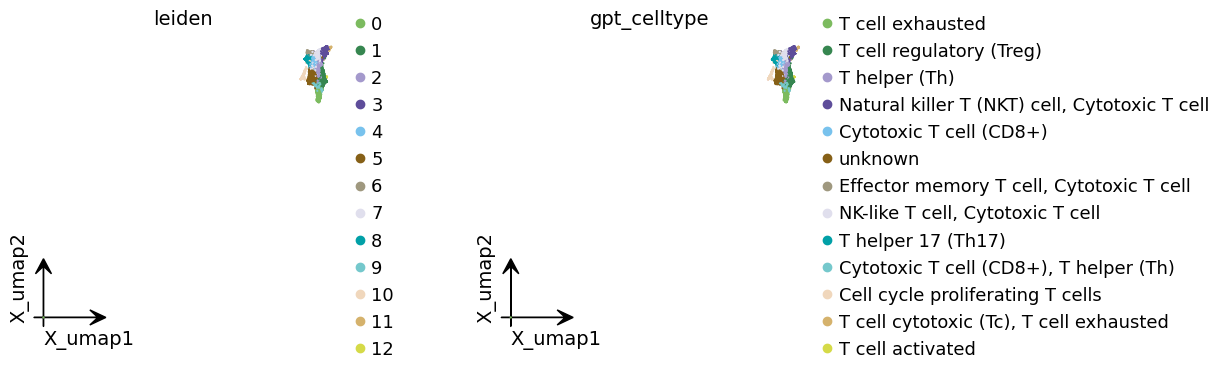

In [22]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [23]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)

gpt_celltype
T cell exhausted                                 15.776128
T cell regulatory (Treg)                         13.131679
T helper (Th)                                    12.977721
Natural killer T (NKT) cell, Cytotoxic T cell    12.932440
Cytotoxic T cell (CD8+)                          11.112117
unknown                                          10.115921
Effector memory T cell, Cytotoxic T cell          6.285093
NK-like T cell, Cytotoxic T cell                  6.221699
T helper 17 (Th17)                                5.116827
Cytotoxic T cell (CD8+), T helper (Th)            2.961420
Cell cycle proliferating T cells                  2.146350
T cell cytotoxic (Tc), T cell exhausted           0.987140
T cell activated                                  0.235465
Name: proportion, dtype: float64


# 总结
疑问：为什么UMAP聚成一小团